# EDA, PCA, ad KMeans

## Data Loading and Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset.csv', na_values='?')

price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

df = df.drop(['stock', 'quarter', 'date', 'next_weeks_close'], axis=1).dropna().reset_index(drop=True)

X = df.copy()

print("Feature matrix shape:", X.shape)


Feature matrix shape: (720, 12)


## Exploratory Data Analysis

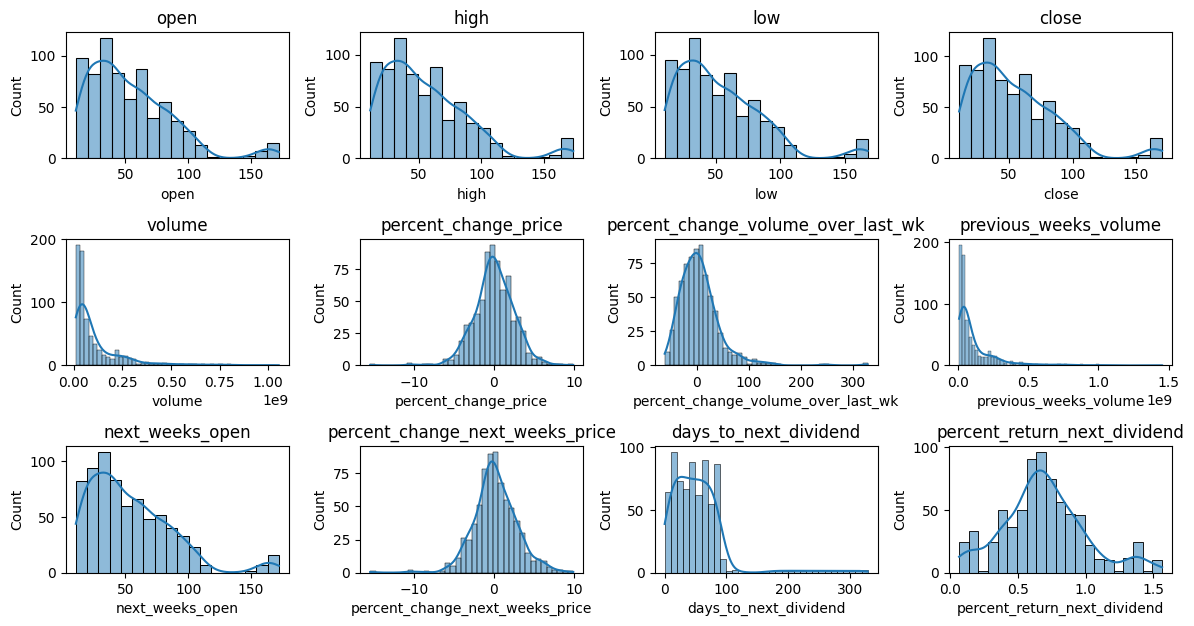

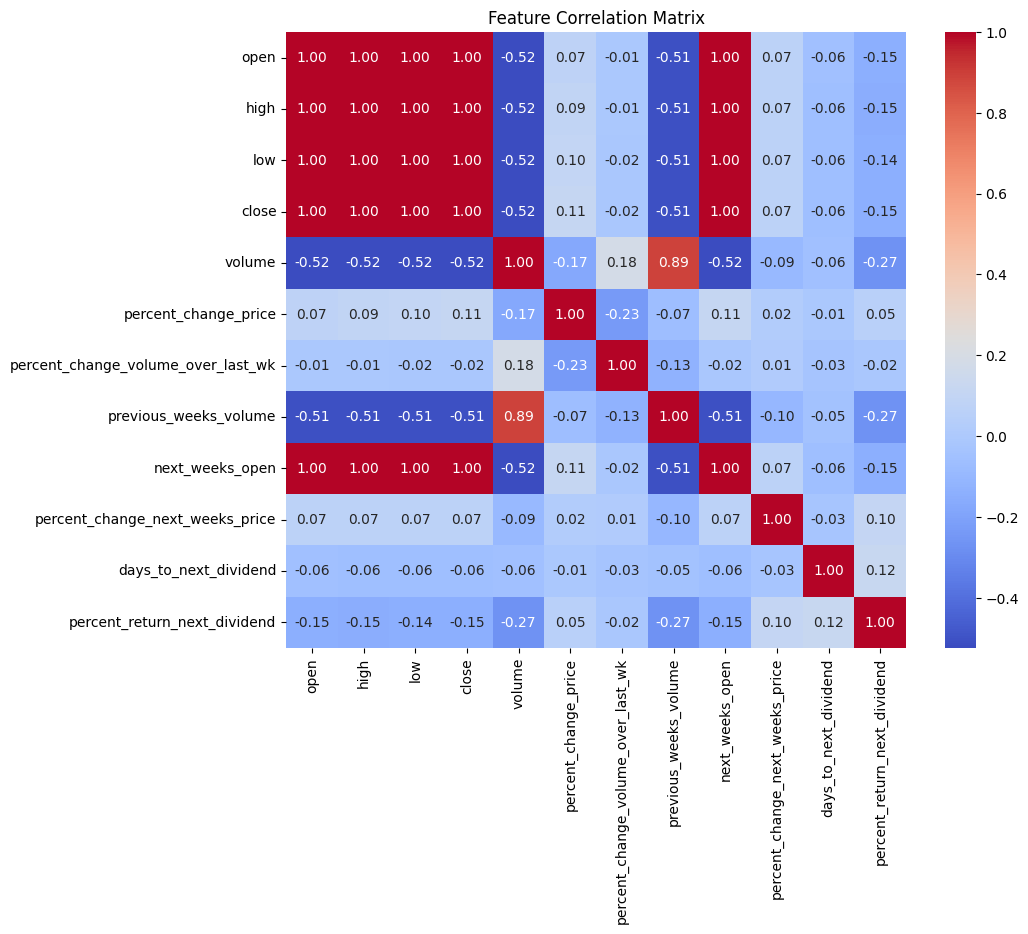

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
for i, col in enumerate(X.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(X_scaled, columns=X.columns).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


## Dimensionality Reduction with PCA

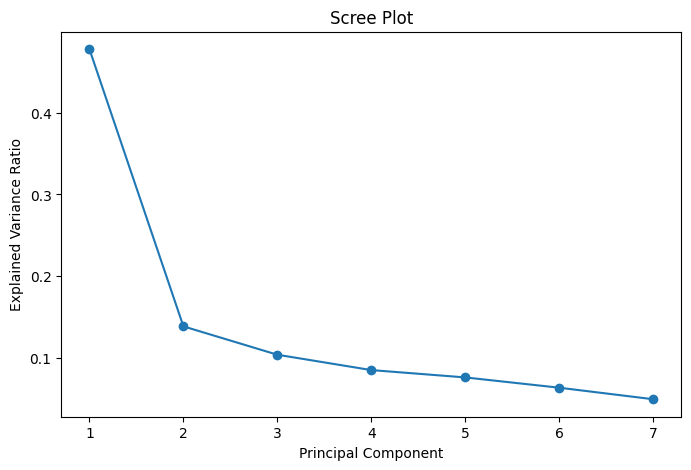

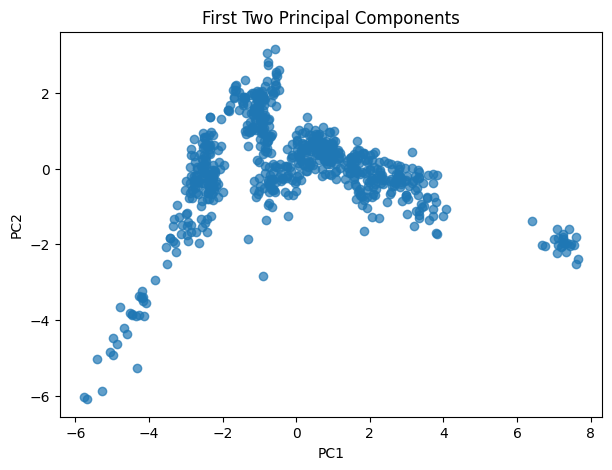

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.show()

# PC1 vs PC2 scatter
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('First Two Principal Components')
plt.show()


## Clustering with KMeans

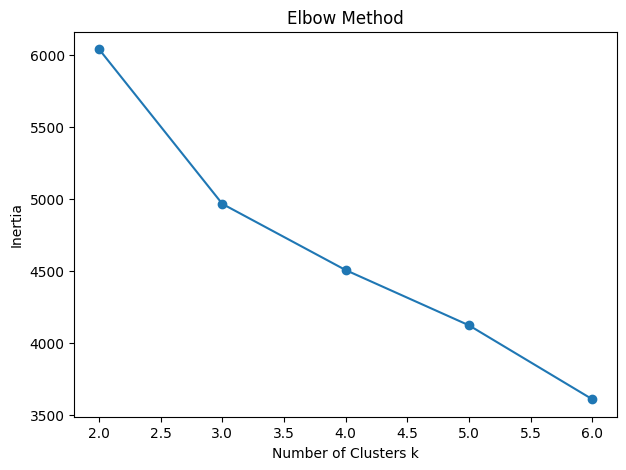

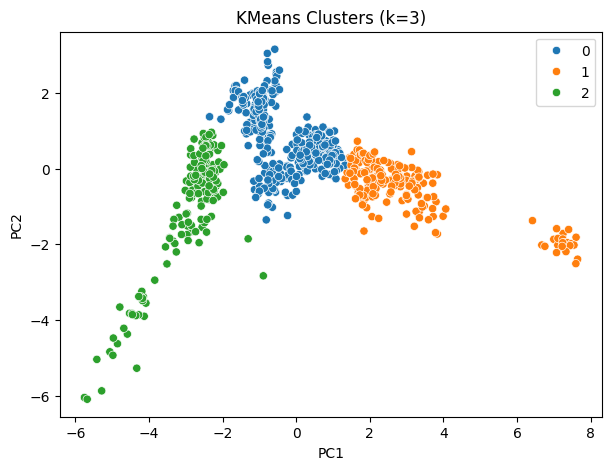

In [4]:
from sklearn.cluster import KMeans

inertias = []
ks = range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42).fit(X_pca)
labels = kmeans.labels_

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'KMeans Clusters (k={k_opt})')
plt.show()


## Cluster Analysis

In [5]:
import pandas as pd
counts = pd.Series(labels).value_counts().sort_index()
display(pd.DataFrame({'Cluster': counts.index, 'Count': counts.values}))

centers = pd.DataFrame(kmeans.cluster_centers_, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
print("PCA-space cluster centers:")
display(centers)



,Cluster,Count
0,0,361
1,1,190
2,2,169


PCA-space cluster centers:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.254532,0.750069,0.067143,-0.034732,-0.121005,-0.040639,-0.083219
1,3.042336,-0.535648,-0.052710,0.017730,0.100328,0.000981,0.103086
2,-2.876672,-1.000011,-0.084164,0.054258,0.145684,0.085705,0.061869


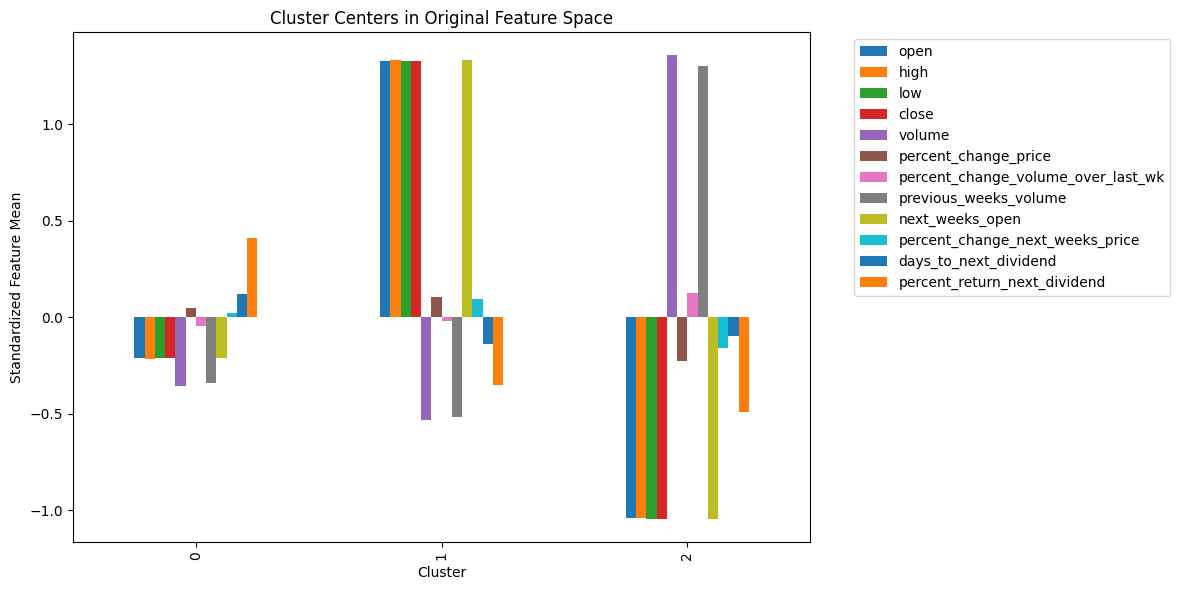

In [6]:
# labels projects to original standardized feature space
X_df = pd.DataFrame(X_scaled, columns=X.columns)
X_df['cluster'] = labels

cluster_means = X_df.groupby('cluster').mean()

cluster_means.plot(kind='bar', figsize=(12, 6))
plt.title('Cluster Centers in Original Feature Space')
plt.xlabel('Cluster')
plt.ylabel('Standardized Feature Mean')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

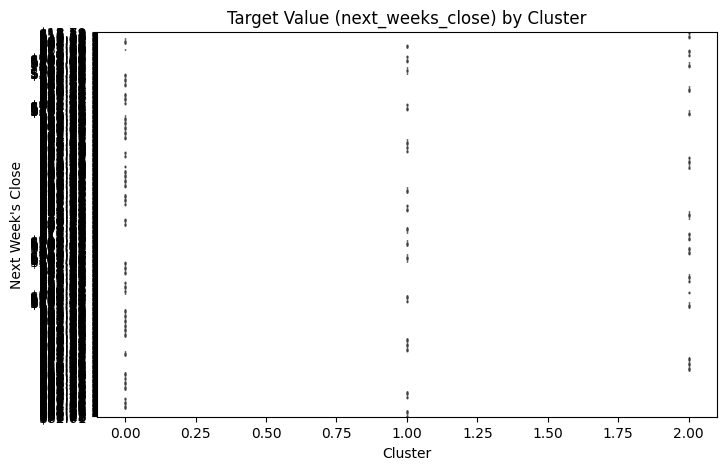

In [7]:
# reload full data
df_full = pd.read_csv('dataset.csv', na_values='?')
df_full = df_full.drop(['stock', 'quarter', 'date'], axis=1).dropna().reset_index(drop=True)

df_full = df_full.drop(['next_weeks_open', 'percent_change_next_weeks_price'], axis=1)

df_full['cluster'] = labels

# Plot boxplot of target vs cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='next_weeks_close', data=df_full)
plt.title('Target Value (next_weeks_close) by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Next Week\'s Close')
plt.show()